## INSTALL

In [ ]:
import sys

REQUIRED_VERSION = (3, 11, 9)
current_version  = sys.version_info[:3]

if current_version != REQUIRED_VERSION:
    raise RuntimeError(
        f"Wrong Python version. Expected 3.11.9, "
        f"got {'.'.join(str(v) for v in current_version)}. "
        "Make sure the correct kernel is selected."
    )

print(f"Python {'.'.join(str(v) for v in current_version)} OK")

%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124 --force-reinstall
%pip install pandas numpy Pillow tqdm scikit-learn xgboost timm

## IMPORTS

In [22]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from PIL import Image
import tqdm
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, train_test_split,
    cross_val_score, ParameterGrid
)
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from xgboost import XGBClassifier
from itertools import product

## DEFINITIONS

In [ ]:
# Load DINOv2 ViT-g/14 - Meta's self-supervised vision transformer.
# Best available frozen feature extractor for image classification (1536-d per image).
# torch.hub downloads the model weights on first run (~4.4 GB), then caches them.
dino_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitg14')
dino_model.eval()

# DINOv2 uses standard ImageNet normalisation at 224x224
dino_preprocess = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def load_and_save_images(image_dir, output_file, has_labels=True):
    # Load every image in a folder, apply the DINOv2 transform, and save to a .pt file.
    # has_labels=True  : folder has one subfolder per class
    # has_labels=False : flat folder of images
    image_tensors = []
    labels        = []
    file_paths    = []

    if has_labels:
        class_names    = sorted(os.listdir(image_dir))
        class_to_index = {name: i for i, name in enumerate(class_names)}

        # get total number of images
        total = sum(
            len(os.listdir(os.path.join(image_dir, cls)))
            for cls in class_names
            if os.path.isdir(os.path.join(image_dir, cls))
        )

        count = 0 # tracker
        
        for class_name in class_names:
            class_folder = os.path.join(image_dir, class_name)
            
            for filename in os.listdir(class_folder):
                
                if not filename.lower().endswith(('.jpg', '.jpeg', '.png')): # if not an image file, skip
                    continue
                
                # extract image
                path = os.path.join(class_folder, filename)
                img  = Image.open(path).convert('RGB')
                image_tensors.append(dino_preprocess(img))
                labels.append(class_to_index[class_name])
                file_paths.append(path)
                
                # update progress
                count += 1
                print(f'{count}/{total}', end='\r')

        # Save tensors, labels, paths, and class mapping to .pt file
        torch.save({
            'tensors':        torch.stack(image_tensors),
            'labels':         torch.tensor(labels),
            'paths':          file_paths,
            'class_to_index': class_to_index
        }, output_file)

    else:
        
        # get list of image files
        image_files = [
            f for f in os.listdir(image_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        
        total = len(image_files) # total number of images
        
        # extract and save each image
        for i, filename in enumerate(image_files, start=1):
            path = os.path.join(image_dir, filename)
            img  = Image.open(path).convert('RGB')
            image_tensors.append(dino_preprocess(img))
            file_paths.append(path)
            
            # update progress
            print(f'{i}/{total}', end='\r')

        # Save tensors and paths to .pt file
        torch.save({'tensors': torch.stack(image_tensors), 'paths': file_paths}, output_file)

    print(f'\nSaved {len(image_tensors)} images to {output_file}') # done!


def extract_features(input_file, output_file):
    # Pass every image through DINOv2

    # load in the images
    data   = torch.load(input_file, weights_only=False)
    images = data['tensors']
    total  = len(images)
    feature_list = []

    # pass each image through DINOv2 and save the resulting feature vector
    with torch.no_grad():
        for i, image in enumerate(images, start=1):
            # add batch dimension: (3,224,224) -> (1,3,224,224)
            feature_vector = dino_model(image.unsqueeze(0))
            feature_vector = feature_vector.squeeze().numpy()  # shape: (1536,)
            feature_list.append(feature_vector)
            print(f'{i}/{total}', end='\r')

    features = np.array(feature_list)
    
    # save features
    torch.save({**data, 'features': features}, output_file)
    print(f'\nExtracted {features.shape} -> saved to {output_file}')

Using cache found in C:\Users\TheRe/.cache\torch\hub\facebookresearch_dinov2_main


In [ ]:
# --- Metrics helper -----------------------------------------------------------

def compute_metrics(true_labels, predicted_labels):
    # compute per-class balance
    classes, counts = np.unique(true_labels, return_counts=True)
    class_balance = {
        int(c): round(100 * n / len(true_labels), 1)
        for c, n in zip(classes, counts)
    }
    
    return {
        'accuracy':      accuracy_score(true_labels, predicted_labels),
        'f1':            f1_score(true_labels, predicted_labels, average='weighted'),
        'precision':     precision_score(true_labels, predicted_labels, average='weighted'),
        'recall':        recall_score(true_labels, predicted_labels, average='weighted'),
        'class_balance': class_balance,
    }


def cv_report(model_name, fold_results):
    # print mean and the std across all folds for each metric
    print(f'--- {model_name} ---')
    for metric in ('accuracy', 'f1', 'precision', 'recall'):
        values = [r[metric] for r in fold_results]
        print(f'  {metric:<9}: {np.mean(values):.4f} +/- {np.std(values):.4f}')
        
    # print the balance for analysis later
    print('  class balance:')
    for class_id, pct in fold_results[0]['class_balance'].items():
        print(f'    class {class_id}: {pct}%')
    print()

# --- MLP model ----------------------------------------------------------------
class MLP(nn.Module):
    # A stack of fully-connected layers with activation and optional dropout
    def __init__(self, input_size, num_classes, hidden_layers=(256, 128),
                 activation=nn.ReLU, dropout=0.0):
        super().__init__()
        
        # variables of the MLP object
        layers       = []
        current_size = input_size
        
        # build the network given input parameters
        for layer_size in hidden_layers:
            layers.append(nn.Linear(current_size, layer_size))
            layers.append(activation())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            current_size = layer_size
            
        # final layer to output class classifier logits
        layers.append(nn.Linear(current_size, num_classes))
        self.network = nn.Sequential(*layers)

    # forward pass through the network
    def forward(self, x):
        return self.network(x)



# --- Classical Classifier functions ------------------------------------------------
# All functions take numpy arrays and return (trained_model, metrics_dict).

def train_logistic_regression(train_features, train_labels, val_features, val_labels, C=1.0):
    
    model = LogisticRegression(C=C, max_iter=2000)
    model.fit(np.asarray(train_features, np.float64), np.asarray(train_labels, np.int64))
    preds = model.predict(np.asarray(val_features, np.float64))
    
    return model, compute_metrics(np.asarray(val_labels, np.int64), preds)


def train_svm(train_features, train_labels, val_features, val_labels,
              kernel='rbf', C=1.0, gamma='scale'):
    
    model = SVC(kernel=kernel, C=C, gamma=gamma, decision_function_shape='ovr')
    model.fit(np.asarray(train_features, np.float64), np.asarray(train_labels, np.int64))
    preds = model.predict(np.asarray(val_features, np.float64))
    
    return model, compute_metrics(np.asarray(val_labels, np.int64), preds)


def train_random_forest(train_features, train_labels, val_features, val_labels, n_trees=300):
    model = RandomForestClassifier(n_estimators=n_trees, max_features='sqrt',
                                   random_state=42, n_jobs=-1)
    
    model.fit(np.asarray(train_features, np.float64), np.asarray(train_labels, np.int64))
    preds = model.predict(np.asarray(val_features, np.float64))
    
    return model, compute_metrics(np.asarray(val_labels, np.int64), preds)


def train_xgboost(train_features, train_labels, val_features, val_labels):
    
    # we use softmax objective for multi-class classification, and logloss as the evaluation metric
    model = XGBClassifier(objective='multi:softmax', eval_metric='mlogloss', verbosity=0)
    model.fit(np.asarray(train_features, np.float64), np.asarray(train_labels, np.int64))
    preds = model.predict(np.asarray(val_features, np.float64))
    
    return model, compute_metrics(np.asarray(val_labels, np.int64), preds)


def train_mlp(train_features, train_labels, val_features, val_labels,
              hidden_layers=(256, 128), activation=nn.ReLU,
              dropout=0.0, epochs=200, learning_rate=1e-3):
    
    device      = 'cuda' if torch.cuda.is_available() else 'cpu' # much faster with GPU, but still works on CPU
    num_classes = len(np.unique(train_labels))

    # move all the data to the device 
    X_train = torch.tensor(np.asarray(train_features, np.float32)).to(device)
    y_train = torch.tensor(np.asarray(train_labels,   np.int64)).to(device)
    X_val   = torch.tensor(np.asarray(val_features,   np.float32)).to(device)
    y_val   = torch.tensor(np.asarray(val_labels,     np.int64)).to(device)

    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=256, shuffle=True) # 256 is default

    # create the MLP model, optimizer, and loss function
    model     = MLP(X_train.shape[1], num_classes, hidden_layers, activation, dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    loss_fn   = nn.CrossEntropyLoss()

    # early stopping, if no improvement occurs we revert to best weights
    best_val_loss    = float('inf')
    best_weights     = None
    no_improve_count = 0

    # training loop
    for epoch in range(epochs):
        model.train() # set model to training mode
        
        # train for one epoch
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        model.eval() # set model to evaluation mode for validation
        with torch.no_grad():
            val_loss = loss_fn(model(X_val), y_val).item() # compute validation loss

        # early stopping check
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_weights     = model.state_dict()
            no_improve_count = 0
        else:
            no_improve_count += 1
            if no_improve_count >= 25:
                break

                
    model.load_state_dict(best_weights) # revert to best weights
    model.eval() # basically turn off dropout for evaluation
    
    with torch.no_grad():
        predictions = model(X_val).argmax(dim=1).cpu().numpy() # get predicted class

    return model, compute_metrics(np.asarray(val_labels, np.int64), predictions)

In [ ]:
def fine_tune_dino(images_file, train_idx, val_idx, num_classes,
                   num_blocks_to_unfreeze=4,
                   backbone_lr=1e-5, head_lr=1e-3,
                   dropout=0.1, epochs=20, batch_size=16):
    
    # NOTE: GPU strongly recommended. On CPU each epoch takes several minutes.
    
    # select device and load the data
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'Device: {device}  (GPU strongly recommended for fine-tuning)')

    data   = torch.load(images_file, weights_only=False)
    images = data['tensors']   # (N, 3, 224, 224)
    labels = data['labels']    # (N,)

    # DINOv2 ViT-g/14 backbone block: a layer that does self-attention
        # Frozen during fine-tuning because the pretrained
        # weights already encode strong visual features so retraining them risks
        # destroying that knowledge while only the task head needs to learn.
        
    # So we:
    # --- Freeze entire backbone, then selectively unfreeze ---
    
    for param in dino_model.parameters(): # freeze all parameters in the backbone
        param.requires_grad = False

    num_total_blocks = len(dino_model.blocks) 
    
    for block in dino_model.blocks[num_total_blocks - num_blocks_to_unfreeze:]: # unfreeze the last few blocks and the final norm layer
        for param in block.parameters():
            param.requires_grad = True
    for param in dino_model.norm.parameters(): # unfreeze final norm layer
        param.requires_grad = True

    trainable = sum(p.numel() for p in dino_model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in dino_model.parameters())
    
    print(f'Trainable backbone params: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)')

    # --- Classification head ---
    head = nn.Sequential(
        nn.Linear(1536, 512),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(512, num_classes),
    ).to(device)

    dino_model.to(device) # move to device

    # we select the AdamW optimizer which is a good default for fine-tuning large pretrained models, with separate learning rates for backbone and head
    optimizer = torch.optim.AdamW([
        {'params': [p for p in dino_model.parameters() if p.requires_grad], 'lr': backbone_lr},
        {'params': head.parameters(), 'lr': head_lr},
    ], weight_decay=1e-4)

    # we use cross-entropy loss for classification
    # cross-entropy loss is: a standard loss function for multi-class classification tasks that measures the difference between predicted probabilities and true class labels, encouraging the model to assign high probabilities to the correct classes.
    loss_fn      = nn.CrossEntropyLoss()
    train_loader = DataLoader(
        TensorDataset(images[train_idx], labels[train_idx]),
        batch_size=batch_size, shuffle=True
    )

    # We only save the weights that actually changed
    unfrozen_prefixes = tuple(
        f'blocks.{i}.'
        for i in range(num_total_blocks - num_blocks_to_unfreeze, num_total_blocks)
    ) + ('norm.',)

    # early stopping variables
    best_val_loss       = float('inf')
    best_backbone_state = None
    best_head_state     = None
    no_improve          = 0

    # retraining loop
    for epoch in range(epochs):
        dino_model.train()
        head.train()
        
        # train for one epoch
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = loss_fn(head(dino_model(X_batch)), y_batch)
            loss.backward()
            optimizer.step()

        # validation step
        dino_model.eval()
        head.eval()
        
        with torch.no_grad():
            val_images = images[val_idx]
            val_feats  = []
            
            for i in range(0, len(val_images), batch_size):
                val_feats.append(dino_model(val_images[i:i+batch_size].to(device)).cpu())
                
            val_feats = torch.cat(val_feats).to(device)
            val_loss  = loss_fn(head(val_feats), labels[val_idx].to(device)).item()

        print(f'Epoch {epoch+1:>3}/{epochs}  val_loss={val_loss:.4f}', end='\r')

        # early stopping check
        if val_loss < best_val_loss:
            best_val_loss       = val_loss
            best_backbone_state = {k: v.cpu().clone() for k, v in dino_model.state_dict().items()
                                   if k.startswith(unfrozen_prefixes)}
            best_head_state     = {k: v.cpu().clone() for k, v in head.state_dict().items()}
            no_improve          = 0
        else:
            no_improve += 1
            if no_improve >= 7:
                print(f'\nEarly stopping at epoch {epoch+1}')
                break

    print(f'\nBest val_loss: {best_val_loss:.4f}')

    # Restore the best weights found during training
    state = dino_model.state_dict()
    state.update(best_backbone_state)
    dino_model.load_state_dict(state)
    head.load_state_dict(best_head_state)

    # Final val predictions
    dino_model.eval()
    head.eval()
    with torch.no_grad():
        val_feats = []
        for i in range(0, len(val_images), batch_size):
            val_feats.append(dino_model(val_images[i:i+batch_size].to(device)).cpu())
        val_preds = head(torch.cat(val_feats).to(device)).argmax(dim=1).cpu().numpy()

    # Move model back to CPU and re-freeze everything for use by extract_features
    dino_model.cpu()
    for param in dino_model.parameters():
        param.requires_grad = False

    return head, compute_metrics(labels[val_idx].numpy(), val_preds)

In [26]:
# kNN: classifies each sample by majority vote among its k nearest neighbours
def train_knn(train_features, train_labels, val_features, val_labels, k=10):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(np.asarray(train_features, np.float64), np.asarray(train_labels, np.int64))
    preds = model.predict(np.asarray(val_features, np.float64))
    return model, compute_metrics(np.asarray(val_labels, np.int64), preds)

In [ ]:
# These helpers are used by the Feature Engineering cell below.

def get_image_id_from_path(file_path, is_train):
    # Extract the image ID from a file path.
    stem = os.path.splitext(os.path.basename(file_path))[0]
    return f'train_{stem}' if is_train else stem


def load_csv_for_images(csv_path, image_ids):
    # Load a CSV (indexed by image_id) and return rows in the same order as image_ids.
    # This ensures the CSV rows line up with our feature matrix rows.
    df = pd.read_csv(csv_path, index_col='image_id')
    return df.loc[image_ids].to_numpy(dtype=np.float32)


def reduce_histogram(histogram, factor):
    # Merge every 'factor' consecutive bins by averaging.
    if factor == 1:
        return histogram
    num_bins = histogram.shape[1]
    if num_bins % factor != 0:
        valid = [f for f in range(1, num_bins + 1) if num_bins % f == 0]
        raise ValueError(
            f'factor {factor} does not divide evenly into {num_bins} bins. '
            f'Valid factors: {valid}'
        )
    return histogram.reshape(histogram.shape[0], num_bins // factor, factor).mean(axis=2)

## PREPROCESSING
Load images, extract DINOv2 features, save to disk. Only needs to run once.

In [ ]:
train_image_dir = r'Data\task2_data\images\train'
test_image_dir  = r'Data\task2_data\images\test'

if not os.path.exists(train_image_dir):
    raise FileNotFoundError(f'Training folder not found: {train_image_dir}')
if not os.path.exists(test_image_dir):
    raise FileNotFoundError(f'Test folder not found: {test_image_dir}')

# Save preprocessed tensors to disk (only needs to run once)
print('Saving images...')
load_and_save_images(train_image_dir, r'Data\task2_data\t2_train.pt', has_labels=True)
load_and_save_images(test_image_dir,  r'Data\task2_data\t2_test.pt',  has_labels=False)

# Extract DINOv2 features (only needs to run once)
print('\nExtracting DINOv2 features...')
extract_features(r'Data\task2_data\t2_train.pt', r'Data\task2_data\t2_train_features.pt')
extract_features(r'Data\task2_data\t2_test.pt',  r'Data\task2_data\t2_test_features.pt')

## FINE-TUNING
Optionally fine-tune the last few DINOv2 blocks on your data, then re-extract features.
Skip this section if you want to use frozen features only.

In [ ]:
# Fine-tune the last 4 DINOv2 blocks on task 2 training images.
# After this runs, re-extract features from the adapted backbone so the rest of
# the notebook (LOAD DATA, EVAL, HYPER SEARCH) automatically benefits.
#
# GPU strongly recommended - on CPU this will take a long time.

raw_pt   = torch.load(r'Data\task2_data\t2_train.pt', weights_only=False)
all_idx  = np.arange(len(raw_pt['labels']))
num_classes = len(np.unique(raw_pt['labels'].numpy()))
train_idx_ft, val_idx_ft = train_test_split(
    all_idx, test_size=0.2, random_state=42,
    stratify=raw_pt['labels'].numpy()
)

fine_tuned_head, ft_metrics = fine_tune_dino(
    images_file            = r'Data\task2_data\t2_train.pt',
    train_idx              = train_idx_ft,
    val_idx                = val_idx_ft,
    num_classes            = num_classes,
    num_blocks_to_unfreeze = 2,   # fewer blocks for the smaller dataset
    backbone_lr            = 5e-6,
    head_lr                = 1e-3,
    dropout                = 0.2,
    epochs                 = 15,
    batch_size             = 8,
)
print(f'Fine-tuned val:  F1={ft_metrics["f1"]:.4f}  Acc={ft_metrics["accuracy"]:.4f}')

# Re-extract features using the now-adapted backbone and save to new files.
# In the PCA cell, set USE_FINETUNED = True to use these.
print('\nRe-extracting features with fine-tuned backbone...')
extract_features(r'Data\task2_data\t2_train.pt', r'Data\task2_data\t2_train_features_ft.pt')
extract_features(r'Data\task2_data\t2_test.pt',  r'Data\task2_data\t2_test_features_ft.pt')
print('Done. Set USE_FINETUNED = True in the PCA cell to use these features.')

## PCA
Reduce the 1536-d DINOv2 features to a smaller number of dimensions.

Train: (417, 1536)  Test: (180, 1536)
Classes: {'American_Goldfinch': 0, 'Blue_Jay': 1, 'Cardinal': 2, 'Herring_Gull': 3, 'House_Sparrow': 4, 'Red_winged_Blackbird': 5, 'Ring_billed_Gull': 6, 'Song_Sparrow': 7, 'Wilson_Warbler': 8, 'Yellow_Warbler': 9}


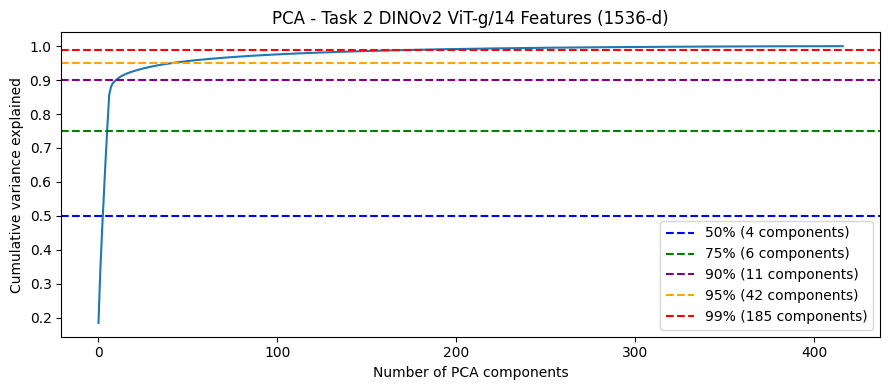

Components needed:
  50% variance -> 4 components
  75% variance -> 6 components
  90% variance -> 11 components
  95% variance -> 42 components
  99% variance -> 185 components

PCA skipped - using full 1536-d features


In [ ]:
# Control Board ------
USE_FINETUNED = True
USE_PCA = False
# --------------------

if USE_FINETUNED:
    train_data = torch.load(r'Data\task2_data\t2_train_features_ft.pt', weights_only=False)
    test_data  = torch.load(r'Data\task2_data\t2_test_features_ft.pt',  weights_only=False)
else:
    train_data = torch.load(r'Data\task2_data\t2_train_features.pt', weights_only=False)
    test_data  = torch.load(r'Data\task2_data\t2_test_features.pt',  weights_only=False)

raw_train_features = train_data['features']
train_labels       = train_data['labels'].numpy()
raw_test_features  = test_data['features']

print(f'Train: {raw_train_features.shape}  Test: {raw_test_features.shape}')
print(f'Classes: {train_data["class_to_index"]}')

# --- Plot variance explained to pick the right number of PCA components ------
# Always plot even if USE_PCA = False, so you can see what you would be reducing to.
pca_full = PCA(random_state=42)
pca_full.fit(raw_train_features)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

n_50 = int(np.searchsorted(cumulative_variance, 0.50)) + 1
n_75 = int(np.searchsorted(cumulative_variance, 0.75)) + 1
n_90 = int(np.searchsorted(cumulative_variance, 0.90)) + 1
n_95 = int(np.searchsorted(cumulative_variance, 0.95)) + 1
n_99 = int(np.searchsorted(cumulative_variance, 0.99)) + 1

plt.figure(figsize=(9, 4))
plt.plot(cumulative_variance, linewidth=1.5)
plt.axhline(0.50, color='blue',   linestyle='--', label=f'50% ({n_50} components)')
plt.axhline(0.75, color='green',  linestyle='--', label=f'75% ({n_75} components)')
plt.axhline(0.90, color='purple', linestyle='--', label=f'90% ({n_90} components)')
plt.axhline(0.95, color='orange', linestyle='--', label=f'95% ({n_95} components)')
plt.axhline(0.99, color='red',    linestyle='--', label=f'99% ({n_99} components)')
plt.xlabel('Number of PCA components')
plt.ylabel('Cumulative variance explained')
plt.title('PCA - Task 2 DINOv2 ViT-g/14 Features (1536-d)')
plt.legend()
plt.tight_layout()
plt.show()

print('Components needed:')
for label, n in [('50%', n_50), ('75%', n_75), ('90%', n_90), ('95%', n_95), ('99%', n_99)]:
    print(f'  {label} variance -> {n} components')

# --- Apply PCA -------------------------------------------------------------------
NUM_PCA_COMPONENTS = n_99   # change to n_50 / n_75 / n_90 / n_95 / n_99 as desired

if USE_PCA:
    pca = PCA(n_components=NUM_PCA_COMPONENTS, random_state=42)
    pca_train_features = pca.fit_transform(raw_train_features)
    pca_test_features  = pca.transform(raw_test_features)
    print(f'\nPCA: 1536-d -> {pca_train_features.shape[1]}-d')
    print(f'Variance retained: {pca.explained_variance_ratio_.sum():.4f}')
else:
    pca_train_features = raw_train_features
    pca_test_features  = raw_test_features
    print(f'\nPCA skipped - using full {pca_train_features.shape[1]}-d features')

## FEATURE ENGINEERING
Combine ResNet PCA features with colour histograms, HOG, and extra features.

In [ ]:
# --- Feature toggles ---------------------------------------------------------
USE_COLOR_HISTOGRAM     = True   # 96-d colour distribution
USE_HOG_FEATURES        = True   # 100-d HOG shape/edge features
USE_EXTRA_FEATURES      = True   # 23-d features

# --- Options -----------------------------------------------------------------
# 96 bins total so valid factors: 1 (keep all), 2->48d, 3->32d, 4->24d, 6->16d, 8->12d
HISTOGRAM_REDUCE_FACTOR = 6

# PCA on the extra features. None = keep all 23 standardised dims.
EXTRA_FEATURES_PCA_DIMS = 12
# -----------------------------------------------------------------------------

# Build the image ID lists so we can match CSV rows to feature matrix rows
train_image_ids = [get_image_id_from_path(p, is_train=True)  for p in train_data['paths']]
test_image_ids  = [get_image_id_from_path(p, is_train=False) for p in test_data['paths']]

# Start with the PCA-reduced features (kept as-is, not rescaled).
combined_train_features = pca_train_features.copy()
combined_test_features  = pca_test_features.copy()

print(f'         PCA features : {pca_train_features.shape[1]:>4d}-d')

if USE_COLOR_HISTOGRAM:
    col_train = load_csv_for_images(r'Data\task2_data\color_histogram.csv', train_image_ids)
    col_test  = load_csv_for_images(r'Data\task2_data\color_histogram.csv', test_image_ids)
    col_train = reduce_histogram(col_train, HISTOGRAM_REDUCE_FACTOR)
    col_test  = reduce_histogram(col_test,  HISTOGRAM_REDUCE_FACTOR)
    
    # standardise: fit only on training data to avoid leaking test info
    scaler = StandardScaler().fit(col_train)
    combined_train_features = np.hstack([combined_train_features, scaler.transform(col_train)])
    combined_test_features  = np.hstack([combined_test_features,  scaler.transform(col_test)])
    note = f'factor={HISTOGRAM_REDUCE_FACTOR}' if HISTOGRAM_REDUCE_FACTOR > 1 else 'full 96 bins'
    print(f'+ colour histogram  : {col_train.shape[1]:>4d}-d  (standardised, {note})')

if USE_HOG_FEATURES:
    hog_train = load_csv_for_images(r'Data\task2_data\hog_pca.csv', train_image_ids)
    hog_test  = load_csv_for_images(r'Data\task2_data\hog_pca.csv', test_image_ids)
    
    # HOG is already PCA-reduced so we keep it as-is
    combined_train_features = np.hstack([combined_train_features, hog_train])
    combined_test_features  = np.hstack([combined_test_features,  hog_test])
    print(f'+ HOG features      : {hog_train.shape[1]:>4d}-d  (as-is)')

if USE_EXTRA_FEATURES:
    extra_train = load_csv_for_images(r'Data\task2_data\additional_features.csv', train_image_ids)
    extra_test  = load_csv_for_images(r'Data\task2_data\additional_features.csv', test_image_ids)
    
    # standardise first (fit on train only)
    scaler = StandardScaler().fit(extra_train)
    extra_train_scaled = scaler.transform(extra_train)
    extra_test_scaled  = scaler.transform(extra_test)
    
    if EXTRA_FEATURES_PCA_DIMS is not None:
        pca_extra          = PCA(n_components=EXTRA_FEATURES_PCA_DIMS, random_state=42)
        extra_train_scaled = pca_extra.fit_transform(extra_train_scaled)
        extra_test_scaled  = pca_extra.transform(extra_test_scaled)
        var_kept = pca_extra.explained_variance_ratio_.sum()
        print(f'+ extra features    : {extra_train_scaled.shape[1]:>4d}-d  (standardised -> PCA, {var_kept:.1%} variance kept)')
    else:
        print(f'+ extra features    : {extra_train_scaled.shape[1]:>4d}-d  (standardised)')
    
    combined_train_features = np.hstack([combined_train_features, extra_train_scaled])
    combined_test_features  = np.hstack([combined_test_features,  extra_test_scaled])

print(f'{"-"*40}')
print(f'  Total               : {combined_train_features.shape[1]:>4d}-d  ({combined_train_features.shape[0]} train, {combined_test_features.shape[0]} test)')

  ResNet PCA features : 1536-d
+ colour histogram  :   16-d  (standardised, factor=6)
+ HOG features      :  100-d  (as-is)
+ extra features    :   12-d  (standardised -> PCA, 99.1% variance kept)
----------------------------------------
  Total               : 1664-d  (417 train, 180 test)


## MODEL EVALUATION

In [ ]:
# --- Control Board -----------------------------------------------------------
SVM_KERNEL = 'rbf'
KNN_K      = 15
RF_TREES   = 300
# -----------------------------------------------------------------------------

cross_val    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
num_features = combined_train_features.shape[1]
print(f'Running 5-fold CV on {num_features}-d features, {len(train_labels)} samples...\n')

# Logistic Regression
fold_results = []
for train_idx, val_idx in cross_val.split(combined_train_features, train_labels):
    _, metrics = train_logistic_regression(
        combined_train_features[train_idx], train_labels[train_idx],
        combined_train_features[val_idx],   train_labels[val_idx]
    )
    fold_results.append(metrics)
cv_report('Logistic Regression (5-fold CV)', fold_results)

# SVM
fold_results = []
for train_idx, val_idx in cross_val.split(combined_train_features, train_labels):
    _, metrics = train_svm(
        combined_train_features[train_idx], train_labels[train_idx],
        combined_train_features[val_idx],   train_labels[val_idx],
        kernel=SVM_KERNEL
    )
    fold_results.append(metrics)
cv_report(f'SVM kernel={SVM_KERNEL} (5-fold CV)', fold_results)

# kNN
fold_results = []
for train_idx, val_idx in cross_val.split(combined_train_features, train_labels):
    _, metrics = train_knn(
        combined_train_features[train_idx], train_labels[train_idx],
        combined_train_features[val_idx],   train_labels[val_idx],
        k=KNN_K
    )
    fold_results.append(metrics)
cv_report(f'kNN k={KNN_K} (5-fold CV)', fold_results)

# Random Forest
fold_results = []
for train_idx, val_idx in cross_val.split(combined_train_features, train_labels):
    _, metrics = train_random_forest(
        combined_train_features[train_idx], train_labels[train_idx],
        combined_train_features[val_idx],   train_labels[val_idx],
        n_trees=RF_TREES
    )
    fold_results.append(metrics)
cv_report(f'Random Forest n_trees={RF_TREES} (5-fold CV)', fold_results)

# XGBoost
fold_results = []
for train_idx, val_idx in cross_val.split(combined_train_features, train_labels):
    _, metrics = train_xgboost(
        combined_train_features[train_idx], train_labels[train_idx],
        combined_train_features[val_idx],   train_labels[val_idx]
    )
    fold_results.append(metrics)
cv_report('XGBoost (5-fold CV)', fold_results)

Running 5-fold CV on 1664-d features, 417 samples...

--- Logistic Regression (5-fold CV) ---
  accuracy : 0.9760 +/- 0.0170
  f1       : 0.9759 +/- 0.0170
  precision: 0.9775 +/- 0.0167
  recall   : 0.9760 +/- 0.0170
  class balance:
    class 0: 10.7%
    class 1: 9.5%
    class 2: 9.5%
    class 3: 9.5%
    class 4: 10.7%
    class 5: 9.5%
    class 6: 10.7%
    class 7: 9.5%
    class 8: 9.5%
    class 9: 10.7%

--- SVM kernel=rbf (5-fold CV) ---
  accuracy : 0.9664 +/- 0.0049
  f1       : 0.9663 +/- 0.0049
  precision: 0.9694 +/- 0.0051
  recall   : 0.9664 +/- 0.0049
  class balance:
    class 0: 10.7%
    class 1: 9.5%
    class 2: 9.5%
    class 3: 9.5%
    class 4: 10.7%
    class 5: 9.5%
    class 6: 10.7%
    class 7: 9.5%
    class 8: 9.5%
    class 9: 10.7%

--- kNN k=15 (5-fold CV) ---
  accuracy : 0.9305 +/- 0.0138
  f1       : 0.9285 +/- 0.0143
  precision: 0.9404 +/- 0.0135
  recall   : 0.9305 +/- 0.0138
  class balance:
    class 0: 10.7%
    class 1: 9.5%
    class 2:

## HYPER PARAM SEARCH

In [ ]:
# --- Search grids ------------------------------------------------------------
# Feature engineering options (n_50, n_75, n_90, n_95, n_99 from the PCA cell)
# None = skip PCA entirely and use the full 1536-d DINOv2 features
SEARCH_PCA_DIMS      = [None, n_90, n_95, n_99]
SEARCH_HIST_FACTOR   = [1, 2, 6]
SEARCH_EXTRA_PCA     = [None, 10, 15]

SEARCH_LOGREG = [{'C': 0.1}, {'C': 1}, {'C': 10}]

SEARCH_SVM = [
    {'kernel': 'linear', 'C': 0.1},
    {'kernel': 'linear', 'C': 1},
    {'kernel': 'linear', 'C': 10},
    {'kernel': 'rbf',    'C': 1,   'gamma': 'scale'},
    {'kernel': 'rbf',    'C': 10,  'gamma': 'scale'},
    {'kernel': 'rbf',    'C': 100, 'gamma': 'scale'},
]

SEARCH_RF = [
    {'n_trees': 200},
    {'n_trees': 300},
]

SEARCH_XGB = [
    {'n_estimators': 100, 'max_depth': 6,  'learning_rate': 0.1},
    {'n_estimators': 200, 'max_depth': 4,  'learning_rate': 0.1},
]

SEARCH_MLP = [
    {'hidden_layers': (128, 64), 'activation': nn.GELU, 'dropout': 0.2, 'learning_rate': 1e-3},
    {'hidden_layers': (64, 32), 'activation': nn.GELU, 'dropout': 0.2, 'learning_rate': 1e-3},
]
# -----------------------------------------------------------------------------

# Pre-load CSVs once to avoid reading disk repeatedly
col_csv   = load_csv_for_images(r'Data\task2_data\color_histogram.csv',     train_image_ids)
hog_csv   = load_csv_for_images(r'Data\task2_data\hog_pca.csv',             train_image_ids)
extra_csv = load_csv_for_images(r'Data\task2_data\additional_features.csv', train_image_ids)

# Pre-compute PCA for each unique dimension count.
# this reduces time for computation

print('Pre-computing PCA projections...')
pca_cache = {}

for num_dims in SEARCH_PCA_DIMS:
    if num_dims is None:
        pca_cache[None] = raw_train_features.astype(np.float64)
        print(f'  None (no PCA): {raw_train_features.shape[1]}-d')
    else:
        pca_obj = PCA(n_components=num_dims, random_state=42)
        pca_cache[num_dims] = pca_obj.fit_transform(raw_train_features).astype(np.float64)
        print(f'  {num_dims} components: done')

# Use the first fold our fixed train/val split
# if we do k-fold here, it would take ages as we would have to do k-times more models
train_idx, val_idx = next(
    StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(raw_train_features, train_labels)
)

print(f'\nTrain: {len(train_idx)} samples  Val: {len(val_idx)} samples')

def build_feature_matrix(num_pca_dims, hist_factor, extra_pca_dims):
    
    # Assemble the combined feature matrix for a given set of options.
    # Scalers and PCA are always fit on the train split to avoid data leakage.
    
    features = pca_cache[num_pca_dims]

    col = reduce_histogram(col_csv.copy(), hist_factor)
    scaler = StandardScaler().fit(col[train_idx])
    features = np.hstack([features, scaler.transform(col)])

    features = np.hstack([features, hog_csv.astype(np.float64)])

    scaler2 = StandardScaler().fit(extra_csv[train_idx])
    extra_scaled = scaler2.transform(extra_csv)
    
    if extra_pca_dims is not None:
        pca_extra = PCA(n_components=extra_pca_dims, random_state=42)
        pca_extra.fit(extra_scaled[train_idx])
        extra_scaled = pca_extra.transform(extra_scaled)
    features = np.hstack([features, extra_scaled])

    return features


# Pre-build all feature matrices and save them
print('\nBuilding feature matrices...')
feature_configs  = list(product(SEARCH_PCA_DIMS, SEARCH_HIST_FACTOR, SEARCH_EXTRA_PCA))
feature_matrices = {}

for config in feature_configs:
    feature_matrices[config] = build_feature_matrix(*config)
    
print(f'  {len(feature_configs)} feature configs ready')

num_model_configs = (len(SEARCH_LOGREG) + len(SEARCH_SVM) + len(SEARCH_RF)
                     + len(SEARCH_XGB) + len(SEARCH_MLP))

total_evals = len(feature_configs) * num_model_configs
print(f'\n{len(feature_configs)} feature configs x {num_model_configs} model configs = {total_evals} total\n')

search_results = []

def record(model_name, param_str, pca_dims, hist_f, extra_pca, num_dims, f1_score_val):
    search_results.append({
        'model':       model_name,
        'params':      param_str,
        'pca_dims':    str(pca_dims) if pca_dims is None else pca_dims,
        'hist_factor': hist_f,
        'extra_pca':   str(extra_pca),
        'total_dims':  num_dims,
        'f1':          float(f1_score_val),
    })

progress = tqdm.tqdm(total=total_evals, desc='Searching')

# --- Pass 1: Logistic Regression and SVM (fast) ------------------------------
progress.set_description('Pass 1/3 - Logistic Regression, SVM')
for pca_d, hist_f, extra_n in feature_configs:
    
    X = feature_matrices[(pca_d, hist_f, extra_n)]
    
    # split into train/val
    X_train_s = X[train_idx]
    X_val_s   = X[val_idx]
    
    # labels
    y_train_s = train_labels[train_idx]
    y_val_s   = train_labels[val_idx]
    
    num_dims  = X.shape[1]

    # Logistic Regression
    for p in SEARCH_LOGREG:
        model = LogisticRegression(max_iter=2000, C=p['C'])
        model.fit(X_train_s, y_train_s)
        
        score = f1_score(y_val_s, model.predict(X_val_s), average='weighted')
        record('LogReg', f"C={p['C']}", pca_d, hist_f, extra_n, num_dims, score)
        
        progress.update(1)

    # SVM
    for p in SEARCH_SVM:
        kwargs = {k: v for k, v in p.items() if k != 'kernel'}
        model  = SVC(kernel=p['kernel'], decision_function_shape='ovr', **kwargs)
        model.fit(X_train_s, y_train_s)
        
        score  = f1_score(y_val_s, model.predict(X_val_s), average='weighted')
        
        gamma_str = f" gamma={p['gamma']}" if 'gamma' in p else ''
        record('SVM', f"kernel={p['kernel']} C={p['C']}{gamma_str}", pca_d, hist_f, extra_n, num_dims, score)
        
        progress.update(1)

# --- Pass 2: Random Forest and XGBoost (medium) ------------------------------
progress.set_description('Pass 2/3 - Random Forest, XGBoost')
for pca_d, hist_f, extra_n in feature_configs:
    
    X = feature_matrices[(pca_d, hist_f, extra_n)]
    
    # split into train/val
    X_train_s = X[train_idx]
    X_val_s   = X[val_idx]
    
    # labels
    y_train_s = train_labels[train_idx]
    y_val_s   = train_labels[val_idx]
    
    num_dims  = X.shape[1]

    # Random Forest
    for p in SEARCH_RF:
        model = RandomForestClassifier(n_estimators=p['n_trees'], max_features='sqrt',
                                       random_state=42, n_jobs=-1)
        
        model.fit(X_train_s, y_train_s)
        score = f1_score(y_val_s, model.predict(X_val_s), average='weighted')
        
        record('RandomForest', f"n_trees={p['n_trees']}", pca_d, hist_f, extra_n, num_dims, score)
        
        progress.update(1)

    # XGBoost
    for p in SEARCH_XGB:
        model = XGBClassifier(objective='multi:softmax', eval_metric='mlogloss', verbosity=0,
                              n_estimators=p['n_estimators'], max_depth=p['max_depth'],
                              learning_rate=p['learning_rate'])
        
        model.fit(X_train_s, y_train_s)
        score = f1_score(y_val_s, model.predict(X_val_s), average='weighted')
        
        record('XGBoost', f"n={p['n_estimators']} depth={p['max_depth']} lr={p['learning_rate']}",
               pca_d, hist_f, extra_n, num_dims, score)
        
        progress.update(1)

# --- Pass 3: MLP (slow) ------------------------------------------------------
progress.set_description('Pass 3/3 - MLP')
for pca_d, hist_f, extra_n in feature_configs:
    X = feature_matrices[(pca_d, hist_f, extra_n)]
    
    # split into train/val
    X_train_s = X[train_idx]
    X_val_s   = X[val_idx]
    
    # labels
    y_train_s = train_labels[train_idx]
    y_val_s   = train_labels[val_idx]
    
    num_dims  = X.shape[1]

    # MLP
    for p in SEARCH_MLP:
        _, metrics = train_mlp(X_train_s, y_train_s, X_val_s, y_val_s,
                               hidden_layers=p['hidden_layers'], activation=p['activation'],
                               dropout=p['dropout'], learning_rate=p['learning_rate'], epochs=300)
        
        record('MLP',
               f"layers={p['hidden_layers']} act={p['activation'].__name__} drop={p['dropout']}",
               pca_d, hist_f, extra_n, num_dims, metrics['f1'])
        
        progress.update(1)

progress.close()

# --- Show top 10 results -----------------------------------------------------
results_df = (
    pd.DataFrame(search_results)
    .sort_values('f1', ascending=False)
    .reset_index(drop=True)
)

W = 112
print(f'\n{"="*W}')
print(f'  TOP 10 -- {len(search_results)} configs evaluated, ranked by weighted F1')
print(f'{"="*W}')
print(f'  {"#":<3}  {"Model":<12}  {"F1":<8}  {"Model params":<38}  {"PCA":<6}  {"Hist":<5}  {"ExtraPCA":<9}  Dims')
print(f'  {"-"*(W-2)}')
for rank, row in results_df.head(10).iterrows():
    print(
        f'  {rank+1:<3}  '
        f'{row["model"]:<12}  '
        f'{row["f1"]:.4f}    '
        f'{str(row["params"]):<38}  '
        f'{str(row["pca_dims"]):<6}  '
        f'{row["hist_factor"]:<5}  '
        f'{row["extra_pca"]:<9}  '
        f'{row["total_dims"]}'
    )
print(f'{"="*W}')
print('\nFull results in results_df')

Pre-computing ResNet PCA projections...
  None (no PCA): 1536-d
  11 components: done
  42 components: done
  185 components: done

Train: 333 samples  Val: 84 samples

Building feature matrices...
  36 feature configs ready

36 feature configs x 15 model configs = 540 total



Pass 3/3 - MLP: 100%|██████████| 540/540 [02:57<00:00,  3.05it/s]                      


  TOP 10 -- 540 configs evaluated, ranked by weighted F1
  #    Model         F1        Model params                            PCA     Hist   ExtraPCA   Dims
  --------------------------------------------------------------------------------------------------------------
  1    MLP           1.0000    layers=(128, 64) act=GELU drop=0.2      185     6      15         316
  2    LogReg        1.0000    C=0.1                                   None    1      None       1755
  3    LogReg        1.0000    C=1                                     None    1      None       1755
  4    MLP           1.0000    layers=(128, 64) act=GELU drop=0.2      185     6      10         311
  5    SVM           1.0000    kernel=linear C=0.1                     None    1      None       1755
  6    SVM           1.0000    kernel=linear C=1                       None    1      None       1755
  7    SVM           1.0000    kernel=linear C=10                      None    1      None       1755
  8    MLP     

## SUBMISSION

In [53]:
# --- Settings ----------------------------------------------------------------
# Choose the best model and feature config from the search above
SUBMISSION_MODEL = 'linear'   # 'linear' | 'svm' | 'rf' | 'xgboost' | 'mlp' | 'knn'

# Feature engineering settings to use for submission
# (copy from the best row in the search results)
SUBMIT_PCA_DIMS    = n_99
SUBMIT_HIST_FACTOR = 1
SUBMIT_EXTRA_PCA   = None

# Model params
LOGREG_C     = 0.1
SVM_PARAMS   = {'kernel': 'linear', 'C': 1}
RF_TREES     = 300
KNN_K        = 10
XGB_PARAMS   = {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1}
MLP_HIDDEN   = (128, 64)
MLP_DROPOUT  = 0.2
MLP_EPOCHS   = 300
MLP_LR       = 1e-3
# -----------------------------------------------------------------------------

def build_submission_features(pca_dims, hist_factor, extra_pca_dims):
    # Build feature matrices for both train and test using the full datasets.
    # Respects USE_PCA, USE_COLOR_HISTOGRAM, USE_HOG_FEATURES, USE_EXTRA_FEATURES,
    # and USE_FINETUNED from the cells above.
    if USE_PCA:
        pca_obj    = PCA(n_components=pca_dims, random_state=42)
        train_feat = pca_obj.fit_transform(raw_train_features).astype(np.float64)
        test_feat  = pca_obj.transform(raw_test_features).astype(np.float64)
    else:
        train_feat = raw_train_features.astype(np.float64)
        test_feat  = raw_test_features.astype(np.float64)

    if USE_COLOR_HISTOGRAM:
        col_train = load_csv_for_images(r'Data\task2_data\color_histogram.csv', train_image_ids)
        col_test  = load_csv_for_images(r'Data\task2_data\color_histogram.csv', test_image_ids)
        col_train = reduce_histogram(col_train, hist_factor)
        col_test  = reduce_histogram(col_test,  hist_factor)
        scaler_col = StandardScaler().fit(col_train)
        train_feat = np.hstack([train_feat, scaler_col.transform(col_train)])
        test_feat  = np.hstack([test_feat,  scaler_col.transform(col_test)])

    if USE_HOG_FEATURES:
        hog_train = load_csv_for_images(r'Data\task2_data\hog_pca.csv', train_image_ids)
        hog_test  = load_csv_for_images(r'Data\task2_data\hog_pca.csv', test_image_ids)
        train_feat = np.hstack([train_feat, hog_train.astype(np.float64)])
        test_feat  = np.hstack([test_feat,  hog_test.astype(np.float64)])

    if USE_EXTRA_FEATURES:
        extra_train = load_csv_for_images(r'Data\task2_data\additional_features.csv', train_image_ids)
        extra_test  = load_csv_for_images(r'Data\task2_data\additional_features.csv', test_image_ids)
        scaler_extra  = StandardScaler().fit(extra_train)
        extra_train_s = scaler_extra.transform(extra_train)
        extra_test_s  = scaler_extra.transform(extra_test)
        if extra_pca_dims is not None:
            pca_extra     = PCA(n_components=extra_pca_dims, random_state=42)
            extra_train_s = pca_extra.fit_transform(extra_train_s)
            extra_test_s  = pca_extra.transform(extra_test_s)
        train_feat = np.hstack([train_feat, extra_train_s])
        test_feat  = np.hstack([test_feat,  extra_test_s])

    return train_feat, test_feat

all_train_features, submit_features = build_submission_features(
    SUBMIT_PCA_DIMS, SUBMIT_HIST_FACTOR, SUBMIT_EXTRA_PCA
)
all_labels = np.asarray(train_labels, np.int64)

print(f'Training {SUBMISSION_MODEL} on {len(all_train_features)} samples, {all_train_features.shape[1]}-d features...')

if SUBMISSION_MODEL == 'linear':
    model = LogisticRegression(C=LOGREG_C, max_iter=2000)
    model.fit(all_train_features, all_labels)
    predictions = model.predict(submit_features)

elif SUBMISSION_MODEL == 'svm':
    model = SVC(decision_function_shape='ovr', **SVM_PARAMS)
    model.fit(all_train_features, all_labels)
    predictions = model.predict(submit_features)

elif SUBMISSION_MODEL == 'rf':
    model = RandomForestClassifier(n_estimators=RF_TREES, max_features='sqrt',
                                   random_state=42, n_jobs=-1)
    model.fit(all_train_features, all_labels)
    predictions = model.predict(submit_features)

elif SUBMISSION_MODEL == 'knn':
    model = KNeighborsClassifier(n_neighbors=KNN_K)
    model.fit(all_train_features, all_labels)
    predictions = model.predict(submit_features)

elif SUBMISSION_MODEL == 'xgboost':
    model = XGBClassifier(objective='multi:softmax', eval_metric='mlogloss', verbosity=0, **XGB_PARAMS)
    model.fit(all_train_features, all_labels)
    predictions = model.predict(submit_features)

elif SUBMISSION_MODEL == 'mlp':
    # Hold out 5% for early stopping
    sub_train_feat, sub_val_feat, sub_train_lbl, sub_val_lbl = train_test_split(
        all_train_features, all_labels, test_size=0.05, random_state=42, stratify=all_labels
    )
    model, _ = train_mlp(
        sub_train_feat, sub_train_lbl, sub_val_feat, sub_val_lbl,
        hidden_layers=MLP_HIDDEN, dropout=MLP_DROPOUT,
        epochs=MLP_EPOCHS, learning_rate=MLP_LR
    )
    model.eval()
    with torch.no_grad():
        device      = next(model.parameters()).device
        predictions = model(
            torch.tensor(np.asarray(submit_features, np.float32)).to(device)
        ).argmax(dim=1).cpu().numpy()

else:
    raise ValueError(f'Unknown model: {SUBMISSION_MODEL}')

image_ids  = [os.path.splitext(os.path.basename(p))[0] for p in test_data['paths']]
submission = pd.DataFrame({'image_id': image_ids, 'class_id': predictions})
submission.to_csv('t2_submission.csv', index=False)
print(f'Saved {len(submission)} predictions to t2_submission.csv')

Training linear on 417 samples, 1755-d features...
Saved 180 predictions to t2_submission.csv
